# Mini-Project 2: Pascal VOC 2007 Semantic Segmentation

This notebook is a report-ready analysis notebook for **Mini-Project 2**. It is organized to satisfy the homework requirements while staying practical on a local machine:

- **Model 1:** custom **U-Net** baseline
- **Model 2:** **DeepLabV3-ResNet50** baseline from `torchvision`
- **Optional model path:** **SAM / SAM2 prompted inference** section that fails gracefully when the package/checkpoints are unavailable
- **Metrics:** Dice, mIoU, pixel accuracy, per-class IoU/accuracy, and optional HD95
- **Visuals:** qualitative mosaics, side-by-side comparisons, and best/worst examples focusing on the **person** class
- **Ablations:** augmentation, loss choice, and model-size / backbone-ready experiment table
- **Report support:** ranked experiment tables, ablation deltas, qualitative figure generation, and a report-ready synthesis cell you can reuse in the write-up

> Update the dataset path in the config cell before running training. The default workflow below loads local checkpoints from this workspace; set `REGENERATE_QUALITATIVE_EXAMPLES = True` only if you want to refresh qualitative figures without retraining.

## Recommended environment

The base system Python in this workspace does **not** currently include the deep-learning stack. Create or activate an environment that contains at least:

```bash
conda create -n shbt-seg python=3.11 -y
conda activate shbt-seg
pip install torch torchvision torchaudio matplotlib numpy pandas pillow jupyter
# optional for HD95
pip install scipy
# optional for SAM2 experiments
pip install git+https://github.com/facebookresearch/sam2.git
```

If you already have a course environment, point Jupyter to that kernel and run the notebook there.

In [1]:
import importlib.util
import sys

REQUIRED_PACKAGES = {
    "torch": "torch",
    "torchvision": "torchvision",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "PIL": "PIL",
}

missing = [
    package
    for package, module_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    raise ImportError(
        "Missing required packages: "
        + ", ".join(missing)
        + "\nInstall them in your notebook kernel before continuing."
    )

print("Quick package check passed.")
print("Python executable:", sys.executable)
print("Note: the next import cell does the real imports and may still take a few seconds the first time.")


Quick package check passed.
Python executable: /shared/courseSharedFolders/163602outer/163602/cs1090b-gpu/bin/python
Note: the next import cell does the real imports and may still take a few seconds the first time.


In [2]:
import json
import math
import os
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

mpl_cache_dir = Path.cwd() / ".mplconfig"
mpl_cache_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_cache_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import VOCSegmentation
from torchvision.models import ResNet50_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, fcn_resnet50
from torchvision.transforms import functional as TF

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)
print("Matplotlib cache dir:", os.environ.get("MPLCONFIGDIR"))


Using device: cuda
Matplotlib cache dir: /shared/home/qiz788/SHBT2/scripts/.mplconfig


In [3]:
VOC_CLASSES = [
    "background", "aeroplane", "bicycle", "bird", "boat", "bottle", "bus",
    "car", "cat", "chair", "cow", "diningtable", "dog", "horse", "motorbike",
    "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]
NUM_CLASSES = len(VOC_CLASSES)
PERSON_CLASS_ID = VOC_CLASSES.index("person")
IGNORE_INDEX = 255
CHECKPOINT_VERSION = 2
CLASS_TO_ID = {name: idx for idx, name in enumerate(VOC_CLASSES)}
ID_TO_CLASS = {idx: name for idx, name in enumerate(VOC_CLASSES)}

print("Number of classes:", NUM_CLASSES)
print(CLASS_TO_ID)

Number of classes: 21
{'background': 0, 'aeroplane': 1, 'bicycle': 2, 'bird': 3, 'boat': 4, 'bottle': 5, 'bus': 6, 'car': 7, 'cat': 8, 'chair': 9, 'cow': 10, 'diningtable': 11, 'dog': 12, 'horse': 13, 'motorbike': 14, 'person': 15, 'pottedplant': 16, 'sheep': 17, 'sofa': 18, 'train': 19, 'tvmonitor': 20}


In [4]:
@dataclass
class SegConfig:
    dataset_root: str = "./VOCtrainval_06-Nov-2007"
    image_size: Tuple[int, int] = (256, 256)
    batch_size: int = 4
    num_workers: int = 0
    train_subset: Optional[int] = None
    val_subset: Optional[int] = None
    epochs: int = 15
    learning_rate: float = 5e-4
    weight_decay: float = 1e-4
    mixed_precision: bool = True
    grad_clip_norm: float = 1.0
    save_dir: str = "./artifacts"

CONFIG = SegConfig()
CONFIG

SegConfig(dataset_root='./VOCtrainval_06-Nov-2007', image_size=(256, 256), batch_size=4, num_workers=0, train_subset=None, val_subset=None, epochs=15, learning_rate=0.0005, weight_decay=0.0001, mixed_precision=True, grad_clip_norm=1.0, save_dir='./artifacts')

In [5]:
def get_notebook_dir() -> Path:
    cwd = Path.cwd().resolve()
    notebook_name = "mini_project_2_pascal_voc_segmentation.ipynb"
    if (cwd / notebook_name).exists():
        return cwd
    if (cwd / "notebooks" / notebook_name).exists():
        return (cwd / "notebooks").resolve()
    for parent in cwd.parents:
        if (parent / "notebooks" / notebook_name).exists():
            return (parent / "notebooks").resolve()
    return cwd


def resolve_notebook_relative_path(path_str: str, must_exist: bool = False) -> Path:
    raw = Path(path_str).expanduser()
    if raw.is_absolute():
        return raw

    notebook_dir = get_notebook_dir()
    cwd = Path.cwd().resolve()
    candidates = [
        (notebook_dir / raw).resolve(),
        (cwd / raw).resolve(),
        (notebook_dir.parent / raw).resolve(),
    ]

    seen = []
    unique_candidates = []
    for candidate in candidates:
        candidate_str = str(candidate)
        if candidate_str not in seen:
            seen.append(candidate_str)
            unique_candidates.append(candidate)

    if must_exist:
        for candidate in unique_candidates:
            if candidate.exists():
                return candidate
    else:
        for candidate in unique_candidates:
            if candidate.exists():
                return candidate
        return unique_candidates[1] if len(unique_candidates) > 1 else unique_candidates[0]

    raise FileNotFoundError(
        f"Could not resolve path '{path_str}' from cwd={cwd} or notebook_dir={notebook_dir}."
    )


def resolve_voc_root(dataset_root: str) -> Path:
    root = resolve_notebook_relative_path(dataset_root, must_exist=True)
    candidates = [
        root,
        root / "VOCdevkit",
        root / "VOCdevkit" / "VOC2007",
        root.parent,
    ]
    for candidate in candidates:
        if candidate.exists():
            jpeg_dir = candidate / "VOCdevkit" / "VOC2007" / "JPEGImages"
            image_sets = candidate / "VOCdevkit" / "VOC2007" / "ImageSets" / "Segmentation"
            if jpeg_dir.exists() and image_sets.exists():
                return candidate
    raise FileNotFoundError(
        f"Could not locate Pascal VOC 2007 files from {root}. "
        "Expected VOCdevkit/VOC2007/JPEGImages and ImageSets/Segmentation."
    )


def resolve_save_dir(save_dir: str) -> Path:
    return resolve_notebook_relative_path(save_dir, must_exist=False)

# Example:
# resolved_root = resolve_voc_root(CONFIG.dataset_root)
# resolved_artifacts = resolve_save_dir(CONFIG.save_dir)


In [6]:
class SegmentationPairTransform:
    def __init__(self, image_size=(256, 256), augment: bool = False):
        self.image_size = image_size
        self.augment = augment
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __call__(self, image: Image.Image, mask: Image.Image):
        image = image.convert("RGB")
        mask = mask.copy()

        if self.augment:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.6:
                angle = random.uniform(-10.0, 10.0)
                max_dx = int(0.05 * image.size[0])
                max_dy = int(0.05 * image.size[1])
                translate = (random.randint(-max_dx, max_dx), random.randint(-max_dy, max_dy))
                scale = random.uniform(0.9, 1.1)
                shear = random.uniform(-5.0, 5.0)
                image = TF.affine(
                    image,
                    angle=angle,
                    translate=translate,
                    scale=scale,
                    shear=shear,
                    interpolation=Image.BILINEAR,
                    fill=0,
                )
                mask = TF.affine(
                    mask,
                    angle=angle,
                    translate=translate,
                    scale=scale,
                    shear=shear,
                    interpolation=Image.NEAREST,
                    fill=IGNORE_INDEX,
                )

            if random.random() < 0.35:
                image = TF.adjust_brightness(image, 1.0 + random.uniform(-0.2, 0.2))
            if random.random() < 0.35:
                image = TF.adjust_contrast(image, 1.0 + random.uniform(-0.2, 0.2))
            if random.random() < 0.2:
                image = TF.adjust_saturation(image, 1.0 + random.uniform(-0.15, 0.15))

        image = TF.resize(image, self.image_size, interpolation=Image.BILINEAR)
        mask = TF.resize(mask, self.image_size, interpolation=Image.NEAREST)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=self.mean, std=self.std)

        mask_np = np.array(mask, dtype=np.int64)
        mask_tensor = torch.as_tensor(mask_np.copy(), dtype=torch.long)
        return image, mask_tensor


class PascalVOCSegmentationDataset(Dataset):
    def __init__(
        self,
        dataset_root: str,
        image_set: str,
        image_size=(256, 256),
        augment: bool = False,
        max_samples: Optional[int] = None,
    ):
        resolved_root = resolve_voc_root(dataset_root)
        self.base = VOCSegmentation(
            root=str(resolved_root),
            year="2007",
            image_set=image_set,
            download=False,
        )
        self.transform = SegmentationPairTransform(image_size=image_size, augment=augment)
        self.indices = list(range(len(self.base)))
        if max_samples is not None:
            self.indices = self.indices[: max_samples]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = self.indices[idx]
        image, mask = self.base[base_idx]
        image, mask = self.transform(image, mask)
        image_id = Path(self.base.images[base_idx]).stem
        return {"image": image, "mask": mask, "image_id": image_id}


def build_dataloaders(config: SegConfig, augment_train: bool = False):
    train_dataset = PascalVOCSegmentationDataset(
        dataset_root=config.dataset_root,
        image_set="train",
        image_size=config.image_size,
        augment=augment_train,
        max_samples=config.train_subset,
    )
    val_dataset = PascalVOCSegmentationDataset(
        dataset_root=config.dataset_root,
        image_set="val",
        image_size=config.image_size,
        augment=False,
        max_samples=config.val_subset,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    return train_dataset, val_dataset, train_loader, val_loader

In [7]:
def voc_colormap(n: int = 256) -> np.ndarray:
    cmap = np.zeros((n, 3), dtype=np.uint8)
    for i in range(n):
        c = i
        for j in range(8):
            cmap[i, 0] |= ((c >> 0) & 1) << (7 - j)
            cmap[i, 1] |= ((c >> 1) & 1) << (7 - j)
            cmap[i, 2] |= ((c >> 2) & 1) << (7 - j)
            c >>= 3
    return cmap

VOC_CMAP = voc_colormap(256)


def denormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return image


def decode_mask(mask: np.ndarray) -> np.ndarray:
    return VOC_CMAP[mask]


def show_dataset_samples(dataset, n: int = 3):
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    for row in range(n):
        sample = dataset[row]
        image = denormalize_image(sample["image"])
        mask = sample["mask"].numpy()
        axes[row, 0].imshow(image)
        axes[row, 0].set_title(f"Image: {sample['image_id']}")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(decode_mask(mask))
        axes[row, 1].set_title("Ground truth mask")
        axes[row, 1].axis("off")
    plt.tight_layout()

## Quick dataset smoke test

Uncomment and run after you update `CONFIG.dataset_root`.

In [8]:
# train_dataset, val_dataset, train_loader, val_loader = build_dataloaders(CONFIG, augment_train=True)
# print(f"Train samples: {len(train_dataset):,}")
# print(f"Validation samples: {len(val_dataset):,}")
# show_dataset_samples(train_dataset, n=2)

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 21, features=(32, 64, 128, 256)):
        super().__init__()
        self.down_blocks = nn.ModuleList()
        self.up_transpose = nn.ModuleList()
        self.up_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        channels = in_channels
        for feature in features:
            self.down_blocks.append(DoubleConv(channels, feature))
            channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2, dropout=0.1)

        for feature in reversed(features):
            self.up_transpose.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.up_blocks.append(DoubleConv(feature * 2, feature))

        self.classifier = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.down_blocks:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for idx, up in enumerate(self.up_transpose):
            x = up(x)
            skip = skips[idx]
            if x.shape[-2:] != skip.shape[-2:]:
                x = TF.resize(x, size=skip.shape[-2:])
            x = torch.cat([skip, x], dim=1)
            x = self.up_blocks[idx](x)
        return self.classifier(x)


def build_torchvision_model(
    model_name: str,
    num_classes: int = NUM_CLASSES,
    use_pretrained_backbone: bool = False,
):
    model_name = model_name.lower()
    kwargs = {"weights": None, "num_classes": num_classes}
    kwargs["weights_backbone"] = ResNet50_Weights.IMAGENET1K_V2 if use_pretrained_backbone else None
    try:
        if model_name == "deeplabv3_resnet50":
            return deeplabv3_resnet50(**kwargs)
        if model_name == "fcn_resnet50":
            return fcn_resnet50(**kwargs)
    except Exception as exc:
        if use_pretrained_backbone:
            print(f"  [WARN] pretrained backbone unavailable for {model_name}: {exc}")
            kwargs["weights_backbone"] = None
            if model_name == "deeplabv3_resnet50":
                return deeplabv3_resnet50(**kwargs)
            if model_name == "fcn_resnet50":
                return fcn_resnet50(**kwargs)
        raise
    raise ValueError(f"Unsupported torchvision segmentation model: {model_name}")


def extract_logits(model_output):
    return model_output["out"] if isinstance(model_output, dict) else model_output

In [10]:
def compute_class_weights(dataset: Dataset, num_classes: int = NUM_CLASSES, ignore_index: int = IGNORE_INDEX):
    counts = torch.zeros(num_classes, dtype=torch.float64)
    for idx in range(len(dataset)):
        mask = dataset[idx]["mask"].view(-1)
        valid_mask = mask[mask != ignore_index]
        if valid_mask.numel() == 0:
            continue
        counts += torch.bincount(valid_mask, minlength=num_classes).double()

    if counts.sum() == 0:
        return torch.ones(num_classes, dtype=torch.float32)

    freqs = counts / counts.sum()
    weights = 1.0 / torch.sqrt(freqs.clamp_min(1e-6))
    weights = weights / weights.mean()
    return weights.float()


def multiclass_dice_loss(
    logits: torch.Tensor,
    target: torch.Tensor,
    num_classes: int = NUM_CLASSES,
    smooth: float = 1.0,
    ignore_index: int = IGNORE_INDEX,
):
    valid_mask = (target != ignore_index)
    if not valid_mask.any():
        return logits.new_tensor(0.0)

    probs = torch.softmax(logits, dim=1)
    safe_target = target.clamp(0, num_classes - 1)
    target_one_hot = F.one_hot(safe_target, num_classes=num_classes)
    target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()
    valid_mask = valid_mask.unsqueeze(1)
    probs = probs * valid_mask
    target_one_hot = target_one_hot * valid_mask
    dims = (0, 2, 3)
    intersection = (probs * target_one_hot).sum(dims)
    union = probs.sum(dims) + target_one_hot.sum(dims)
    dice = (2.0 * intersection + smooth) / (union + smooth)
    present_classes = target_one_hot.sum(dims) > 0
    dice = dice[present_classes] if present_classes.any() else dice
    return 1.0 - dice.mean()


def segmentation_loss(
    logits: torch.Tensor,
    target: torch.Tensor,
    loss_name: str = "ce_dice",
    class_weights: Optional[torch.Tensor] = None,
    ignore_index: int = IGNORE_INDEX,
    label_smoothing: float = 0.0,
):
    loss_name = loss_name.lower()
    ce = F.cross_entropy(
        logits,
        target,
        weight=class_weights,
        ignore_index=ignore_index,
        label_smoothing=label_smoothing,
    )
    if loss_name == "ce":
        return ce
    if loss_name == "dice":
        return multiclass_dice_loss(logits, target, ignore_index=ignore_index)
    if loss_name == "ce_dice":
        return ce + multiclass_dice_loss(logits, target, ignore_index=ignore_index)
    raise ValueError(f"Unknown loss: {loss_name}")

In [11]:
def confusion_matrix_from_predictions(pred: torch.Tensor, target: torch.Tensor, num_classes: int = NUM_CLASSES):
    pred = pred.detach().view(-1).cpu()
    target = target.detach().view(-1).cpu()
    valid = (target >= 0) & (target < num_classes)
    encoded = target[valid] * num_classes + pred[valid]
    hist = torch.bincount(encoded, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return hist


def metrics_from_confusion_matrix(hist: torch.Tensor, human_class_id: int = PERSON_CLASS_ID):
    hist = hist.float()
    tp = hist.diag()
    gt_count = hist.sum(dim=1)
    pred_count = hist.sum(dim=0)
    union = gt_count + pred_count - tp

    per_class_iou = torch.where(union > 0, tp / union, torch.nan)
    per_class_acc = torch.where(gt_count > 0, tp / gt_count, torch.nan)
    per_class_dice = torch.where(gt_count + pred_count > 0, 2 * tp / (gt_count + pred_count), torch.nan)

    metrics = {
        "pixel_accuracy": (tp.sum() / hist.sum()).item() if hist.sum() > 0 else float("nan"),
        "mIoU": torch.nanmean(per_class_iou).item(),
        "mean_dice": torch.nanmean(per_class_dice).item(),
        "human_iou": per_class_iou[human_class_id].item(),
        "human_accuracy": per_class_acc[human_class_id].item(),
        "per_class_iou": {VOC_CLASSES[i]: float(per_class_iou[i]) for i in range(NUM_CLASSES)},
        "per_class_accuracy": {VOC_CLASSES[i]: float(per_class_acc[i]) for i in range(NUM_CLASSES)},
    }
    return metrics


def binary_hd95(pred_mask: np.ndarray, true_mask: np.ndarray) -> float:
    try:
        from scipy.spatial.distance import cdist
    except ImportError:
        return float("nan")

    pred_points = np.argwhere(pred_mask > 0)
    true_points = np.argwhere(true_mask > 0)
    if len(pred_points) == 0 or len(true_points) == 0:
        return float("nan")
    d_pred = cdist(pred_points, true_points).min(axis=1)
    d_true = cdist(true_points, pred_points).min(axis=1)
    return float(max(np.percentile(d_pred, 95), np.percentile(d_true, 95)))


def batch_hd95(pred: torch.Tensor, target: torch.Tensor, class_id: int = PERSON_CLASS_ID) -> List[float]:
    scores = []
    pred_np = pred.cpu().numpy()
    target_np = target.cpu().numpy()
    for pred_mask, true_mask in zip(pred_np, target_np):
        scores.append(binary_hd95(pred_mask == class_id, true_mask == class_id))
    return scores


def per_sample_person_iou(pred_mask: torch.Tensor, true_mask: torch.Tensor, class_id: int = PERSON_CLASS_ID) -> float:
    pred_positive = pred_mask == class_id
    true_positive = true_mask == class_id
    intersection = (pred_positive & true_positive).sum().item()
    union = (pred_positive | true_positive).sum().item()
    return float(intersection / union) if union > 0 else float("nan")

In [12]:
class AverageMeter:
    def __init__(self):
        self.total = 0.0
        self.count = 0

    def update(self, value, n=1):
        self.total += value * n
        self.count += n

    @property
    def avg(self):
        return self.total / max(self.count, 1)


def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    device,
    loss_name="ce_dice",
    class_weights: Optional[torch.Tensor] = None,
    label_smoothing: float = 0.0,
    grad_clip_norm: Optional[float] = None,
):
    model.train()
    loss_meter = AverageMeter()
    total_batches = len(loader)

    for batch_idx, batch in enumerate(loader, 1):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        optimizer.zero_grad(set_to_none=True)

        autocast_enabled = scaler is not None and device.type == "cuda"
        with torch.amp.autocast("cuda", enabled=autocast_enabled):
            logits = extract_logits(model(images))
            loss = segmentation_loss(
                logits,
                masks,
                loss_name=loss_name,
                class_weights=class_weights,
                label_smoothing=label_smoothing,
            )

        if scaler is not None and device.type == "cuda":
            scaler.scale(loss).backward()
            if grad_clip_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            optimizer.step()

        loss_meter.update(loss.item(), images.size(0))
        print(
            f"  train [{batch_idx:3d}/{total_batches}]  "
            f"loss={loss_meter.avg:.4f}",
            end="\r", flush=True,
        )

    print()  # newline after final \r
    return {"train_loss": loss_meter.avg}


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    device,
    loss_name="ce_dice",
    compute_hd95=True,
    class_weights: Optional[torch.Tensor] = None,
    label_smoothing: float = 0.0,
):
    model.eval()
    hist = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)
    loss_meter = AverageMeter()
    hd95_scores = []
    examples = []
    total_batches = len(loader)

    for batch_idx, batch in enumerate(loader, 1):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        logits = extract_logits(model(images))
        loss = segmentation_loss(
            logits,
            masks,
            loss_name=loss_name,
            class_weights=class_weights,
            label_smoothing=label_smoothing,
        )
        preds = logits.argmax(dim=1)

        hist += confusion_matrix_from_predictions(preds, masks)
        loss_meter.update(loss.item(), images.size(0))
        if compute_hd95:
            hd95_scores.extend(batch_hd95(preds, masks))

        print(
            f"  val   [{batch_idx:3d}/{total_batches}]  "
            f"loss={loss_meter.avg:.4f}",
            end="\r", flush=True,
        )

        for image_tensor, mask_tensor, pred_tensor, image_id in zip(
            images.cpu(), masks.cpu(), preds.cpu(), batch["image_id"]
        ):
            examples.append(
                {
                    "image_id": image_id,
                    "image": denormalize_image(image_tensor),
                    "mask": mask_tensor.numpy(),
                    "prediction": pred_tensor.numpy(),
                    "person_iou": per_sample_person_iou(pred_tensor, mask_tensor),
                }
            )

    print()  # newline after final \r
    metrics = metrics_from_confusion_matrix(hist)
    metrics["val_loss"] = loss_meter.avg
    metrics["hd95_person"] = float(np.nanmean(hd95_scores)) if hd95_scores else float("nan")
    return metrics, hist, examples


In [13]:
def plot_confusion_matrix(hist: torch.Tensor, class_names: Sequence[str] = VOC_CLASSES, figsize=(10, 8), title: str = 'Pixel-level confusion matrix'):
    hist = hist.detach().float().cpu().numpy()
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(hist, cmap="magma")
    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()


def show_prediction_triplets(examples: Sequence[dict], title: str, max_items: int = 6):
    subset = list(examples)[:max_items]
    if not subset:
        print("No examples to visualize yet.")
        return
    fig, axes = plt.subplots(len(subset), 3, figsize=(12, 4 * len(subset)))
    if len(subset) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row, example in enumerate(subset):
        axes[row, 0].imshow(example["image"])
        axes[row, 0].set_title(f"Image: {example['image_id']}")
        axes[row, 1].imshow(decode_mask(example["mask"]))
        axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(decode_mask(example["prediction"]))
        axes[row, 2].set_title(f"Prediction | person IoU={example['person_iou']:.3f}")
        for col in range(3):
            axes[row, col].axis("off")
    fig.suptitle(title)
    plt.tight_layout()


def show_best_and_worst_person_examples(examples: Sequence[dict], count: int = 3):
    filtered = [ex for ex in examples if not math.isnan(ex["person_iou"])]
    if not filtered:
        print("No person-containing examples were found yet.")
        return
    best = sorted(filtered, key=lambda x: x["person_iou"], reverse=True)[:count]
    worst = sorted(filtered, key=lambda x: x["person_iou"])[:count]
    show_prediction_triplets(best, title=f"Top {count} best person-class examples", max_items=count)
    show_prediction_triplets(worst, title=f"Top {count} worst person-class examples", max_items=count)

def show_prediction_mosaic(examples: Sequence[dict], title: str = "Segmentation mosaic",
                            n_cols: int = 4, max_items: int = 12):
    """Mosaic-style grid: each column = (image | GT | pred) compacted into 3 rows."""
    subset = list(examples)[:max_items]
    if not subset:
        print("No examples to visualize.")
        return
    n = len(subset)
    n_cols = min(n_cols, n)
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(3 * n_rows, n_cols, figsize=(3 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(3 * n_rows, n_cols)
    for idx, ex in enumerate(subset):
        row_base = (idx // n_cols) * 3
        col = idx % n_cols
        axes[row_base, col].imshow(ex["image"])
        axes[row_base, col].set_title(ex["image_id"], fontsize=6)
        axes[row_base + 1, col].imshow(decode_mask(ex["mask"]))
        axes[row_base + 2, col].imshow(decode_mask(ex["prediction"]))
        if col == 0:
            axes[row_base, col].set_ylabel("Image", fontsize=8)
            axes[row_base + 1, col].set_ylabel("Ground truth", fontsize=8)
            axes[row_base + 2, col].set_ylabel("Prediction", fontsize=8)
        iou = ex["person_iou"]
        label = f"pIoU={iou:.2f}" if not math.isnan(iou) else ""
        axes[row_base + 2, col].set_xlabel(label, fontsize=6)
        for r in range(3):
            axes[row_base + r, col].set_xticks([])
            axes[row_base + r, col].set_yticks([])
    # hide unused axes
    for idx in range(len(subset), n_rows * n_cols):
        row_base = (idx // n_cols) * 3
        col = idx % n_cols
        for r in range(3):
            axes[row_base + r, col].axis("off")
    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()


def plot_per_class_iou(metrics: dict, title: str = "Per-class IoU"):
    per_iou = metrics["per_class_iou"]
    names = list(per_iou.keys())
    values = [v if not (isinstance(v, float) and math.isnan(v)) else 0.0 for v in per_iou.values()]
    positions = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ["steelblue" if n != "person" else "tomato" for n in names]
    ax.bar(positions, values, color=colors)
    ax.set_xticks(positions)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_ylabel("IoU")
    ax.set_title(title)
    ax.axhline(metrics.get("mIoU", 0), color="green", linestyle="--", label=f"mIoU={metrics.get('mIoU',0):.3f}")
    ax.legend()
    plt.tight_layout()


In [14]:
EXPERIMENTS = {
    "unet_small_no_aug": {
        "model_type": "unet",
        "features": (32, 64, 128, 256),
        "augment": False,
        "loss_name": "ce_dice",
        "epochs": 30,
        "lr": 5e-4,
        "use_class_weights": True,
        "label_smoothing": 0.0,
    },
    "unet_small_with_aug": {
        "model_type": "unet",
        "features": (32, 64, 128, 256),
        "augment": True,
        "loss_name": "ce_dice",
        "epochs": 30,
        "lr": 5e-4,
        "use_class_weights": True,
        "label_smoothing": 0.0,
    },
    "deeplabv3_resnet50": {
        "model_type": "deeplabv3_resnet50",
        "augment": True,
        "loss_name": "ce_dice",
        "epochs": 30,
        "lr": 2e-4,
        "use_class_weights": True,
        "use_pretrained_backbone": True,
        "label_smoothing": 0.0,
    },
    "unet_small_ce_only": {
        "model_type": "unet",
        "features": (32, 64, 128, 256),
        "augment": True,
        "loss_name": "ce",
        "epochs": 30,
        "lr": 5e-4,
        "use_class_weights": True,
        "label_smoothing": 0.05,
    },
    "unet_small_dice_only": {
        "model_type": "unet",
        "features": (32, 64, 128, 256),
        "augment": True,
        "loss_name": "dice",
        "epochs": 30,
        "lr": 5e-4,
        "use_class_weights": False,
        "label_smoothing": 0.0,
    },
    "unet_wider_with_aug": {
        "model_type": "unet",
        "features": (64, 128, 256, 512),
        "augment": True,
        "loss_name": "ce_dice",
        "epochs": 30,
        "lr": 3e-4,
        "use_class_weights": True,
        "label_smoothing": 0.0,
    },
    # "fcn_resnet50": {...}
    # "unet_dice_only": {"model_type": "unet", "loss_name": "dice", ...}
}


def build_model(experiment_cfg: Dict):
    model_type = experiment_cfg["model_type"]
    if model_type == "unet":
        return UNet(num_classes=NUM_CLASSES, features=experiment_cfg.get("features", (32, 64, 128, 256)))
    return build_torchvision_model(
        model_type,
        num_classes=NUM_CLASSES,
        use_pretrained_backbone=experiment_cfg.get("use_pretrained_backbone", False),
    )

In [15]:
def run_experiment(
    name: str,
    config: SegConfig,
    experiment_cfg: Dict,
    force_retrain: bool = False,
    regenerate_examples: bool = False,
    resume_training: bool = False,
    additional_epochs: int = 0,
    early_stopping_patience: int = 8,
    resume_lr_factor: float = 0.5,
    resume_min_lr: float = 5e-5,
):
    save_dir = resolve_save_dir(config.save_dir)
    ckpt_path = save_dir / f"{name}.pt"

    print(f"\n{'='*62}")
    print(f"  Experiment : {name}")
    print(f"{'='*62}")

    ckpt = None
    start_epoch = 1
    history = []
    best_state = None
    last_state = None
    best_metrics = None
    best_hist = None
    best_miou = -float("inf")
    epochs_without_improvement = 0

    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        ckpt_version = ckpt.get("checkpoint_version", 0)
        is_legacy_resume_compatible = (
            resume_training
            and ckpt.get("model_state") is not None
            and ckpt.get("history") is not None
            and ckpt.get("metrics") is not None
        )
        if ckpt_version != CHECKPOINT_VERSION and not is_legacy_resume_compatible:
            print(
                f"  [STALE] checkpoint version {ckpt_version} != {CHECKPOINT_VERSION}; "
                "retraining with the improved pipeline."
            )
            ckpt = None
        elif ckpt_version != CHECKPOINT_VERSION and is_legacy_resume_compatible:
            print(
                f"  [LEGACY] checkpoint version {ckpt_version} detected; "
                "resuming from saved weights/history without optimizer state."
            )
        elif not force_retrain and not resume_training:
            history_df = pd.DataFrame(ckpt["history"])
            metrics = ckpt["metrics"]
            confusion_mat = ckpt["confusion_matrix"]
            result = {
                "name": name,
                "model": None,
                "history": history_df,
                "metrics": metrics,
                "confusion_matrix": confusion_mat,
                "examples": [],
            }
            print(f"  [LOADED]  checkpoint: {ckpt_path}")
            print(f"  Model      : {experiment_cfg['model_type']}")
            print(f"  Best mIoU  : {metrics['mIoU']:.4f}")
            if regenerate_examples:
                model = build_model(experiment_cfg).to(device)
                model.load_state_dict(ckpt["model_state"])
                num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
                print(f"  Params     : {num_params:,}")
                print("  Regenerating examples from val set ...")
                _, _, _, val_loader = build_dataloaders(config, augment_train=False)
                class_weights = ckpt.get("class_weights")
                if class_weights is not None:
                    class_weights = class_weights.to(device)
                _, _, examples = evaluate_model(
                    model,
                    val_loader,
                    device,
                    loss_name=experiment_cfg.get("loss_name", "ce_dice"),
                    class_weights=class_weights,
                    label_smoothing=experiment_cfg.get("label_smoothing", 0.0),
                )
                result["model"] = model
                result["examples"] = examples
            else:
                print("  Using saved history/metrics only (no retraining, no val-set rerun).")
                print("  Set REGENERATE_QUALITATIVE_EXAMPLES = True if you need mosaics/examples.")
            print(f"{'='*62}\n")
            return result

    train_dataset, val_dataset, train_loader, val_loader = build_dataloaders(
        config,
        augment_train=experiment_cfg.get("augment", False),
    )
    class_weights = None
    if experiment_cfg.get("use_class_weights", True) and experiment_cfg.get("loss_name", "ce_dice") != "dice":
        class_weights = compute_class_weights(train_dataset).to(device)
    model = build_model(experiment_cfg).to(device)
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"  Model      : {experiment_cfg['model_type']}  ({num_params:,} params)")
    print(f"  Train/Val  : {len(train_dataset):,} / {len(val_dataset):,} samples")
    print(f"  Loss       : {experiment_cfg.get('loss_name', 'ce_dice')}")
    print(f"  Augment    : {experiment_cfg.get('augment', False)}")
    if experiment_cfg.get("use_pretrained_backbone", False):
        print("  Backbone   : ImageNet-pretrained if locally available")
    if class_weights is not None:
        print(
            f"  Class wts  : background={class_weights[0].item():.3f}  "
            f"person={class_weights[PERSON_CLASS_ID].item():.3f}"
        )
    print(f"  Device     : {device}")
    print(f"  Save dir   : {save_dir}")
    print()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=experiment_cfg.get("lr", config.learning_rate),
        weight_decay=config.weight_decay,
    )
    target_epochs = experiment_cfg.get("epochs", config.epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=config.mixed_precision and device.type == "cuda")

    if ckpt is not None:
        print(f"  [RESUME] checkpoint: {ckpt_path}")
        resume_state = ckpt.get("last_model_state") or ckpt.get("model_state")
        if resume_state is not None:
            model.load_state_dict(resume_state)
        history = list(ckpt.get("history", []))
        # Keep only epochs within the planned budget (avoids off-by-one / duplicate rows).
        history = [h for h in history if isinstance(h, dict) and h.get("epoch", 0) <= target_epochs]
        history.sort(key=lambda h: h.get("epoch", 0))
        last_completed_epoch = max((h.get("epoch", 0) for h in history), default=0)
        start_epoch = last_completed_epoch + 1
        best_metrics = ckpt.get("metrics")
        best_hist = ckpt.get("confusion_matrix")
        best_state = ckpt.get("model_state")
        if best_metrics is not None:
            best_miou = float(best_metrics.get("mIoU", -float("inf")))
        if ckpt.get("optimizer_state") is not None:
            optimizer.load_state_dict(ckpt["optimizer_state"])
        else:
            # Legacy checkpoints may not have optimizer state; restart at a lower LR for stable fine-tuning.
            resume_lr = max(experiment_cfg.get("lr", config.learning_rate) * resume_lr_factor, resume_min_lr)
            for group in optimizer.param_groups:
                group["lr"] = resume_lr
            print(
                "  [INFO] optimizer state missing; resuming from weights/history only. "
                f"Using fallback lr={resume_lr:.6f}."
            )
        if ckpt.get("scaler_state") is not None and device.type == "cuda":
            scaler.load_state_dict(ckpt["scaler_state"])
        if additional_epochs > 0:
            target_epochs = last_completed_epoch + additional_epochs
        elif target_epochs < last_completed_epoch:
            print(
                f"  [INFO] checkpoint spans up to epoch {last_completed_epoch}; "
                f"target budget is {target_epochs} (history rows were trimmed)."
            )
        print(f"  Resume     : epoch {start_epoch} -> {target_epochs}")

    val_examples = []
    if ckpt is not None and start_epoch > target_epochs:
        print(
            f"  [SKIP] No training steps needed (last completed epoch {last_completed_epoch}, target {target_epochs})."
        )
        history_df = pd.DataFrame(history)
        if last_state is None:
            last_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if best_state is None and ckpt.get("model_state") is not None:
            best_state = {k: v.detach().cpu().clone() for k, v in ckpt["model_state"].items()}
        save_dir.mkdir(parents=True, exist_ok=True)
        torch.save({
            "checkpoint_version": CHECKPOINT_VERSION,
            "model_state": best_state,
            "last_model_state": last_state,
            "history": history_df.to_dict(orient="records"),
            "metrics": best_metrics,
            "confusion_matrix": best_hist,
            "class_weights": class_weights.detach().cpu() if class_weights is not None else None,
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": None,
            "scaler_state": scaler.state_dict() if device.type == "cuda" else None,
        }, ckpt_path)
        print(f"  [SAVED]  {ckpt_path}")
        return {
            "name": name,
            "model": model,
            "history": history_df,
            "metrics": best_metrics,
            "confusion_matrix": best_hist,
            "examples": val_examples,
        }

    remaining_epochs = max(target_epochs - start_epoch + 1, 1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=remaining_epochs,
        eta_min=resume_min_lr,
    )
    if ckpt is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])

    exp_start = time.time()
    for epoch in range(start_epoch, target_epochs + 1):
        print(f"  Epoch {epoch}/{target_epochs}  |  lr={optimizer.param_groups[0]['lr']:.6f}")
        epoch_start = time.time()

        train_stats = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            device,
            loss_name=experiment_cfg.get("loss_name", "ce_dice"),
            class_weights=class_weights,
            label_smoothing=experiment_cfg.get("label_smoothing", 0.0),
            grad_clip_norm=config.grad_clip_norm,
        )
        val_metrics, val_hist, val_examples = evaluate_model(
            model,
            val_loader,
            device,
            loss_name=experiment_cfg.get("loss_name", "ce_dice"),
            class_weights=class_weights,
            label_smoothing=experiment_cfg.get("label_smoothing", 0.0),
        )
        scheduler.step()

        elapsed = time.time() - epoch_start
        epoch_stats = {
            "epoch": epoch,
            **train_stats,
            **{k: v for k, v in val_metrics.items() if not isinstance(v, dict)},
            "epoch_minutes": elapsed / 60.0,
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history.append(epoch_stats)

        is_best = epoch_stats["mIoU"] > best_miou
        best_tag = "  <- best" if is_best else ""
        print(
            f"    loss  train={epoch_stats['train_loss']:.4f}  val={epoch_stats['val_loss']:.4f}"
            f"  |  mIoU={epoch_stats['mIoU']:.4f}  px_acc={epoch_stats['pixel_accuracy']:.4f}"
            f"  |  human_iou={epoch_stats['human_iou']:.4f}"
            f"  |  {elapsed:.0f}s{best_tag}"
        )

        last_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if is_best:
            best_miou = epoch_stats["mIoU"]
            best_metrics = val_metrics
            best_hist = val_hist
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if early_stopping_patience > 0 and epochs_without_improvement >= early_stopping_patience:
                print(f"  [EARLY STOP] no mIoU improvement for {early_stopping_patience} epochs.")
                break

    total_time = time.time() - exp_start
    print(f"\n  Done  best mIoU={best_miou:.4f}  |  total time: {total_time/60:.1f} min")
    print(f"{'='*62}\n")

    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_metrics = val_metrics
        best_hist = val_hist
    if last_state is None:
        last_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    history_df = pd.DataFrame(history)
    save_dir.mkdir(parents=True, exist_ok=True)
    torch.save({
        "checkpoint_version": CHECKPOINT_VERSION,
        "model_state": best_state,
        "last_model_state": last_state,
        "history": history_df.to_dict(orient="records"),
        "metrics": best_metrics,
        "confusion_matrix": best_hist,
        "class_weights": class_weights.detach().cpu() if class_weights is not None else None,
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict() if device.type == "cuda" else None,
    }, ckpt_path)
    print(f"  [SAVED]  {ckpt_path}")

    return {
        "name": name,
        "model": model,
        "history": history_df,
        "metrics": best_metrics,
        "confusion_matrix": best_hist,
        "examples": val_examples,
    }


## Main training / evaluation driver

The weak results likely come from a few structural issues rather than one bad hyperparameter: the original setup trained for too few epochs, used relatively weak augmentation, and trained `DeepLabV3` from scratch. The next cell exposes resume controls and a stronger training configuration so you can continue from existing checkpoints instead of restarting blindly.

In [16]:
RUN_TRAINING = True
FORCE_RETRAIN = False
RESUME_TRAINING = True
ADDITIONAL_EPOCHS = 0
EARLY_STOPPING_PATIENCE = 6
RESUME_LR_FACTOR = 0.35
RESUME_MIN_LR = 5e-5
# Keep the default path fast: load saved checkpoint metrics only.
# Set this to True only if you want to refresh validation-set figures from checkpoints.
REGENERATE_QUALITATIVE_EXAMPLES = False
TOP_K_QUALITATIVE_MODELS = 3
SELECTED_EXPERIMENTS = [
    "unet_small_no_aug",
    "unet_small_with_aug",
    "unet_small_ce_only",
    "unet_small_dice_only",
    "unet_wider_with_aug",
    "deeplabv3_resnet50",
]

experiment_results = {}

if RUN_TRAINING:
    save_dir = resolve_save_dir(CONFIG.save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    print(
        "Resume mode:" if RESUME_TRAINING else "Fast report mode:" if not FORCE_RETRAIN else "Fresh training mode:",
        (
            f"continuing selected checkpoints for +{ADDITIONAL_EPOCHS} epochs."
            if RESUME_TRAINING else
            "loading saved checkpoints only."
            if (not FORCE_RETRAIN and not REGENERATE_QUALITATIVE_EXAMPLES) else
            "reusing checkpoints with qualitative-example regeneration."
            if not FORCE_RETRAIN else
            "training selected experiments (reusing checkpoints only when available)."
        ),
    )
    print(f"Resolved artifact directory: {save_dir}")
    for experiment_name in SELECTED_EXPERIMENTS:
        experiment_results[experiment_name] = run_experiment(
            experiment_name,
            CONFIG,
            EXPERIMENTS[experiment_name],
            force_retrain=FORCE_RETRAIN,
            regenerate_examples=REGENERATE_QUALITATIVE_EXAMPLES,
            resume_training=RESUME_TRAINING,
            additional_epochs=ADDITIONAL_EPOCHS,
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            resume_lr_factor=RESUME_LR_FACTOR,
            resume_min_lr=RESUME_MIN_LR,
        )
else:
    print(
        "Set RUN_TRAINING = True to load saved checkpoints, resume training, or retrain. "
        "Keep FORCE_RETRAIN = False for the fast report path, or set RESUME_TRAINING = True to continue from a checkpoint."
    )


Resume mode: continuing selected checkpoints for +0 epochs.
Resolved artifact directory: /shared/home/qiz788/SHBT2/artifacts

  Experiment : unet_small_no_aug
  Model      : unet  (7,763,701 params)
  Train/Val  : 209 / 213 samples
  Loss       : ce_dice
  Augment    : False
  Class wts  : background=0.112  person=0.315
  Device     : cuda
  Save dir   : /shared/home/qiz788/SHBT2/artifacts

  [RESUME] checkpoint: /shared/home/qiz788/SHBT2/artifacts/unet_small_no_aug.pt
  Resume     : epoch 31 -> 30
  [SKIP] No training steps needed (last completed epoch 30, target 30).
  [SAVED]  /shared/home/qiz788/SHBT2/artifacts/unet_small_no_aug.pt

  Experiment : unet_small_with_aug
  Model      : unet  (7,763,701 params)
  Train/Val  : 209 / 213 samples
  Loss       : ce_dice
  Augment    : True
  Class wts  : background=0.115  person=0.318
  Device     : cuda
  Save dir   : /shared/home/qiz788/SHBT2/artifacts

  [RESUME] checkpoint: /shared/home/qiz788/SHBT2/artifacts/unet_small_with_aug.pt
  Re

In [19]:
COMPARISON_EPOCH = 30


def _history_row_for_epoch(history_df: pd.DataFrame, compare_epoch: int = COMPARISON_EPOCH) -> pd.Series:
    if history_df.empty:
        raise ValueError("History dataframe is empty.")
    eligible = history_df[history_df["epoch"] <= compare_epoch]
    if eligible.empty:
        eligible = history_df
    return eligible.sort_values("epoch").iloc[-1]


def summarize_experiments(results: Dict[str, Dict], compare_epoch: int = COMPARISON_EPOCH) -> pd.DataFrame:
    rows = []
    for name, result in results.items():
        history_df = result["history"].copy()
        row_at_epoch = _history_row_for_epoch(history_df, compare_epoch=compare_epoch)
        rows.append(
            {
                "experiment": name,
                "epoch_for_comparison": int(row_at_epoch["epoch"]),
                "pixel_accuracy": float(row_at_epoch["pixel_accuracy"]),
                "mIoU": float(row_at_epoch["mIoU"]),
                "mean_dice": float(row_at_epoch["mean_dice"]),
                "hd95_person": float(row_at_epoch["hd95_person"]),
                "human_iou": float(row_at_epoch["human_iou"]),
                "human_accuracy": float(row_at_epoch["human_accuracy"]),
                "val_loss": float(row_at_epoch["val_loss"]),
            }
        )
    return pd.DataFrame(rows).sort_values(by="mIoU", ascending=False).reset_index(drop=True)


def build_per_class_iou_df(results: Dict[str, Dict]) -> pd.DataFrame:
    rows = []
    for name, result in results.items():
        row = {"experiment": name}
        row.update(result["metrics"]["per_class_iou"])
        rows.append(row)
    return pd.DataFrame(rows).set_index("experiment")


def build_ablation_dataframe(results: Dict[str, Dict]) -> pd.DataFrame:
    ablation_pairs = [
        ("Augmentation", "unet_small_no_aug", "unet_small_with_aug"),
        ("Loss function (CE vs Dice)", "unet_small_ce_only", "unet_small_dice_only"),
        ("Model size (small vs wide)", "unet_small_with_aug", "unet_wider_with_aug"),
        ("Architecture (U-Net vs DeepLab)", "unet_small_with_aug", "deeplabv3_resnet50"),
    ]
    rows = []
    for ablation_name, exp_a, exp_b in ablation_pairs:
        if exp_a not in results or exp_b not in results:
            continue
        metrics_a = results[exp_a]["metrics"]
        metrics_b = results[exp_b]["metrics"]
        row = {
            "ablation": ablation_name,
            "baseline": exp_a,
            "comparison": exp_b,
        }
        for metric_name in ["mIoU", "mean_dice", "pixel_accuracy", "human_iou", "hd95_person", "val_loss"]:
            row[f"baseline_{metric_name}"] = metrics_a[metric_name]
            row[f"comparison_{metric_name}"] = metrics_b[metric_name]
            row[f"delta_{metric_name}"] = metrics_b[metric_name] - metrics_a[metric_name]
        rows.append(row)
    return pd.DataFrame(rows)


def make_history_long_df(results: Dict[str, Dict], compare_epoch: int = COMPARISON_EPOCH) -> pd.DataFrame:
    frames = []
    for name, result in results.items():
        history_df = result["history"].copy()
        history_df = history_df[history_df["epoch"] <= compare_epoch].copy()
        history_df["experiment"] = name
        frames.append(history_df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def preview_text_file(path: Path, max_lines: int = 18) -> str:
    if not path.exists():
        return f"Missing file: {path}"
    lines = path.read_text(errors="replace").splitlines()
    preview = lines[:max_lines]
    if len(lines) > max_lines:
        preview.append("...")
    return "\n".join(preview)


def build_best_metric_table(summary_df: pd.DataFrame) -> pd.DataFrame:
    metric_directions = {
        "mIoU": "max",
        "mean_dice": "max",
        "pixel_accuracy": "max",
        "human_iou": "max",
        "human_accuracy": "max",
        "hd95_person": "min",
        "val_loss": "min",
    }
    rows = []
    for metric_name, direction in metric_directions.items():
        if direction == "max":
            idx = summary_df[metric_name].idxmax()
        else:
            idx = summary_df[metric_name].idxmin()
        rows.append(
            {
                "metric": metric_name,
                "direction": direction,
                "best_experiment": summary_df.loc[idx, "experiment"],
                "value": summary_df.loc[idx, metric_name],
            }
        )
    return pd.DataFrame(rows)


def build_key_findings(summary_df: pd.DataFrame, ablation_df: pd.DataFrame, compare_epoch: int = COMPARISON_EPOCH) -> List[str]:
    findings = [f"All summary and ablation metrics are compared at epoch {compare_epoch} for fairness."]
    if summary_df.empty:
        return findings

    best_overall = summary_df.iloc[0]
    findings.append(
        f"Best overall overlap: {best_overall['experiment']} with mIoU={best_overall['mIoU']:.4f} and mean Dice={best_overall['mean_dice']:.4f}."
    )

    best_pixel = summary_df.loc[summary_df['pixel_accuracy'].idxmax()]
    findings.append(
        f"Best pixel accuracy: {best_pixel['experiment']} at {best_pixel['pixel_accuracy']:.4f}."
    )

    best_human = summary_df.loc[summary_df['human_iou'].idxmax()]
    findings.append(
        f"Best person-class IoU: {best_human['experiment']} at {best_human['human_iou']:.4f}."
    )

    best_hd95 = summary_df.loc[summary_df['hd95_person'].idxmin()]
    findings.append(
        f"Best person HD95 (lower is better): {best_hd95['experiment']} at {best_hd95['hd95_person']:.2f}."
    )

    for ablation_name in ["Augmentation", "Loss function (CE vs Dice)", "Model size (small vs wide)", "Architecture (U-Net vs DeepLab)"]:
        rows = ablation_df[ablation_df['ablation'] == ablation_name]
        if rows.empty:
            continue
        row = rows.iloc[0]
        findings.append(
            f"{ablation_name}: ΔmIoU={row['delta_mIoU']:+.4f}, Δhuman_iou={row['delta_human_iou']:+.4f}, Δhd95_person={row['delta_hd95_person']:+.2f}."
        )

    return findings


In [20]:
def plot_training_history(history_df: pd.DataFrame, title: str, compare_epoch: int = COMPARISON_EPOCH):
    history_df = history_df[history_df["epoch"] <= compare_epoch].copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    history_df.plot(x="epoch", y="train_loss", ax=axes[0], marker="o", title=f"Train loss (<= {compare_epoch} epochs)")
    history_df.plot(x="epoch", y="val_loss", ax=axes[1], marker="o", title=f"Validation loss (<= {compare_epoch} epochs)")
    history_df.plot(x="epoch", y="mIoU", ax=axes[2], marker="o", title=f"Validation mIoU (<= {compare_epoch} epochs)")
    for ax in axes:
        ax.set_xlim(1, compare_epoch)
    fig.suptitle(title)
    plt.tight_layout()


def plot_metric_across_experiments(
    results: Dict[str, Dict],
    metric_name: str,
    title: str,
    ylabel: str,
    compare_epoch: int = COMPARISON_EPOCH,
):
    fig, ax = plt.subplots(figsize=(8, 5))
    for exp_name, result in results.items():
        history_df = result["history"]
        history_df = history_df[history_df["epoch"] <= compare_epoch]
        ax.plot(history_df["epoch"], history_df[metric_name], marker="o", label=exp_name)
    ax.set_xlabel("Epoch")
    ax.set_xlim(1, compare_epoch)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.2)
    plt.tight_layout()


def plot_per_class_heatmap(per_class_df: pd.DataFrame, title: str = "Per-class IoU heatmap"):
    matrix = per_class_df.fillna(0.0).to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(12, max(4, 0.6 * len(per_class_df.index))))
    im = ax.imshow(matrix, aspect="auto", cmap="viridis")
    ax.set_xticks(np.arange(len(per_class_df.columns)))
    ax.set_xticklabels(per_class_df.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(per_class_df.index)))
    ax.set_yticklabels(per_class_df.index)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="IoU")
    plt.tight_layout()


## Post-training analysis (checkpoint/log-driven)

This section is designed for the **report workflow**: it assumes the trained `.pt` checkpoints already exist in `artifacts/` and uses the saved checkpoint histories, metrics, confusion matrices, and `train.log` preview for analysis.

It does **not** retrain the models unless `FORCE_RETRAIN = True`. By default it stays in fast checkpoint-analysis mode; turn on `REGENERATE_QUALITATIVE_EXAMPLES` only if you want refreshed validation-set figures from the saved checkpoints.


In [21]:
if experiment_results:
    artifacts_dir = resolve_save_dir(CONFIG.save_dir)
    train_log_path = resolve_notebook_relative_path("train.log", must_exist=False)
    summary_df = summarize_experiments(experiment_results)
    per_class_df = build_per_class_iou_df(experiment_results).round(3)
    ablation_df = build_ablation_dataframe(experiment_results).round(4)
    best_metric_df = build_best_metric_table(summary_df).round(4)
    history_long_df = make_history_long_df(experiment_results)
    key_findings = build_key_findings(summary_df, ablation_df)

    print("Artifact-driven analysis mode: using saved checkpoints/history/metrics.")
    print(f"Artifacts dir: {artifacts_dir}")
    print(f"Train log: {train_log_path if train_log_path.exists() else 'not found'}")

    if train_log_path.exists():
        print("\n=== train.log preview ===")
        print(preview_text_file(train_log_path, max_lines=14))

    print("\n=== Key findings ===")
    for finding in key_findings:
        print(f"- {finding}")

    print("\n=== Ranked experiment summary ===")
    display(summary_df.round(4))

    print("\n=== Best-by-metric table ===")
    display(best_metric_df)

    print("\n=== Ablation delta table ===")
    display(ablation_df)
else:
    print("No experiment results yet. Load the saved checkpoints first.")


Artifact-driven analysis mode: using saved checkpoints/history/metrics.
Artifacts dir: /shared/home/qiz788/SHBT2/artifacts
Train log: not found

=== Key findings ===
- All summary and ablation metrics are compared at epoch 30 for fairness.
- Best overall overlap: deeplabv3_resnet50 with mIoU=0.0891 and mean Dice=0.1414.
- Best pixel accuracy: unet_small_ce_only at 0.7140.
- Best person-class IoU: unet_small_dice_only at 0.2660.
- Best person HD95 (lower is better): unet_small_dice_only at 76.71.
- Augmentation: ΔmIoU=+0.0057, Δhuman_iou=+0.0254, Δhd95_person=+0.61.
- Loss function (CE vs Dice): ΔmIoU=+0.0067, Δhuman_iou=+0.1159, Δhd95_person=-5.27.
- Model size (small vs wide): ΔmIoU=-0.0082, Δhuman_iou=-0.0235, Δhd95_person=+5.48.
- Architecture (U-Net vs DeepLab): ΔmIoU=+0.0343, Δhuman_iou=-0.0369, Δhd95_person=+1.32.

=== Ranked experiment summary ===


,experiment,epoch_for_comparison,pixel_accuracy,mIoU,mean_dice,hd95_person,human_iou,human_accuracy,val_loss
0,deeplabv3_resnet50,30,0.5977,0.0891,0.1414,92.8063,0.1368,0.3150,3.3274
1,unet_small_dice_only,30,0.6927,0.0557,0.0754,76.7078,0.2660,0.4935,0.7961
2,unet_small_with_aug,30,0.6998,0.0535,0.0740,91.0327,0.1477,0.3582,3.2887
3,unet_small_no_aug,30,0.6947,0.0492,0.0663,90.8778,0.1483,0.4035,3.3165
4,unet_small_ce_only,23,0.7140,0.0485,0.0636,85.5471,0.1510,0.3702,2.9979
5,unet_wider_with_aug,30,0.6875,0.0463,0.0610,97.4451,0.1459,0.4503,3.3030



=== Best-by-metric table ===


,metric,direction,best_experiment,value
0,mIoU,max,deeplabv3_resnet50,0.0891
1,mean_dice,max,deeplabv3_resnet50,0.1414
2,pixel_accuracy,max,unet_small_ce_only,0.7140
3,human_iou,max,unet_small_dice_only,0.2660
4,human_accuracy,max,unet_small_dice_only,0.4935
5,hd95_person,min,unet_small_dice_only,76.7078
6,val_loss,min,unet_small_dice_only,0.7961



=== Ablation delta table ===


,ablation,baseline,comparison,baseline_mIoU,comparison_mIoU,delta_mIoU,baseline_mean_dice,comparison_mean_dice,delta_mean_dice,baseline_pixel_accuracy,...,delta_pixel_accuracy,baseline_human_iou,comparison_human_iou,delta_human_iou,baseline_hd95_person,comparison_hd95_person,delta_hd95_person,baseline_val_loss,comparison_val_loss,delta_val_loss
0,Augmentation,unet_small_no_aug,unet_small_with_aug,0.0492,0.0548,0.0057,0.0663,0.0764,0.0101,0.6947,...,0.0023,0.1483,0.1737,0.0254,90.8778,91.4903,0.6125,3.3165,3.2768,-0.0398
1,Loss function (CE vs Dice),unet_small_ce_only,unet_small_dice_only,0.0490,0.0557,0.0067,0.0645,0.0754,0.0109,0.7203,...,-0.0276,0.1501,0.2660,0.1159,81.9823,76.7078,-5.2746,3.0093,0.7961,-2.2131
2,Model size (small vs wide),unet_small_with_aug,unet_wider_with_aug,0.0548,0.0466,-0.0082,0.0764,0.0611,-0.0153,0.6970,...,0.0012,0.1737,0.1502,-0.0235,91.4903,96.9696,5.4794,3.2768,3.3101,0.0333
3,Architecture (U-Net vs DeepLab),unet_small_with_aug,deeplabv3_resnet50,0.0548,0.0891,0.0343,0.0764,0.1414,0.0650,0.6970,...,-0.0993,0.1737,0.1368,-0.0369,91.4903,92.8063,1.3160,3.2768,3.3274,0.0506


### Training dynamics reconstructed from saved histories

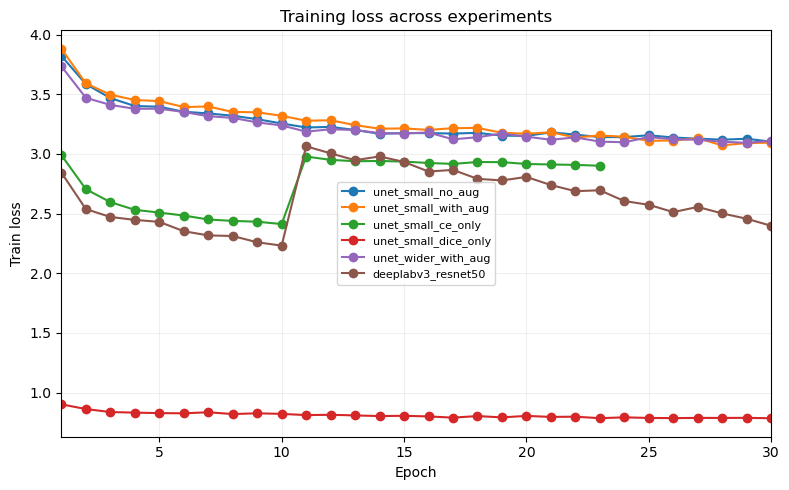

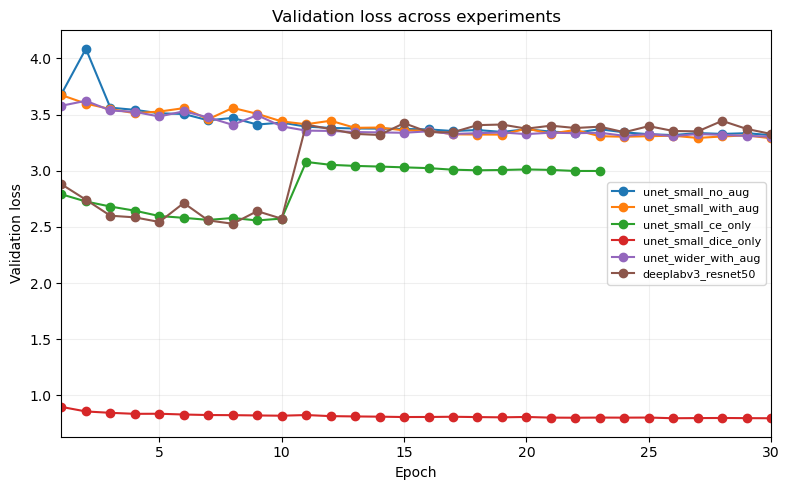

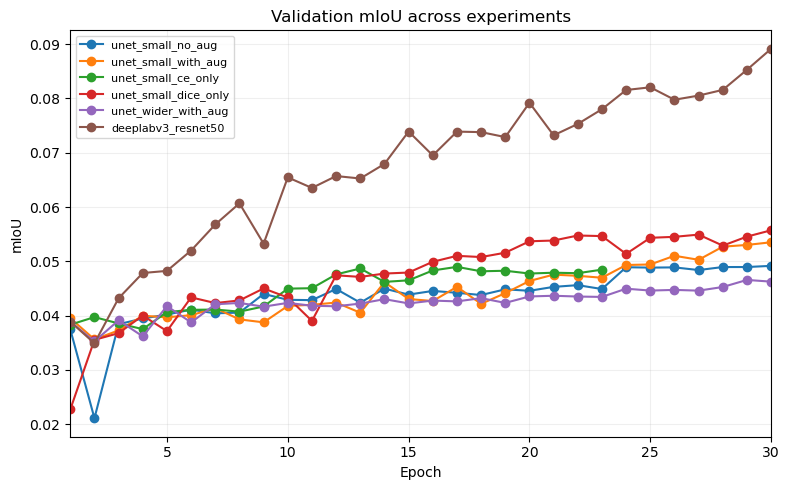

In [22]:
if experiment_results:
    plot_metric_across_experiments(experiment_results, "train_loss", "Training loss across experiments", "Train loss")
    plt.show()
    plot_metric_across_experiments(experiment_results, "val_loss", "Validation loss across experiments", "Validation loss")
    plt.show()
    plot_metric_across_experiments(experiment_results, "mIoU", "Validation mIoU across experiments", "mIoU")
    plt.show()
else:
    print("No experiment histories loaded.")


### Class-wise behavior from saved checkpoint metrics

Per-class IoU table:


,background,aeroplane,bicycle,bird,boat,bottle,bus,car,cat,chair,...,diningtable,dog,horse,motorbike,person,pottedplant,sheep,sofa,train,tvmonitor
experiment,,,,,,,,,,,,,,,,,,,,,
unet_small_no_aug,0.730,0.000,0.000,0.018,0.000,0.000,0.000,0.054,0.000,0.000,...,0.001,0.000,0.000,0.081,0.148,0.0,0.000,0.000,0.000,0.000
unet_small_with_aug,0.738,0.000,0.000,0.000,0.000,0.000,0.059,0.042,0.012,0.000,...,0.000,0.005,0.018,0.058,0.174,0.0,0.000,0.000,0.039,0.007
unet_small_ce_only,0.747,0.000,0.000,0.000,0.000,0.000,0.011,0.001,0.000,0.000,...,0.000,0.000,0.000,0.116,0.150,0.0,0.000,0.000,0.000,0.003
unet_small_dice_only,0.741,0.000,0.000,0.000,0.000,0.000,0.011,0.000,0.002,0.009,...,0.000,0.047,0.008,0.068,0.266,0.0,0.000,0.000,0.000,0.017
unet_wider_with_aug,0.732,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,...,0.002,0.000,0.001,0.090,0.150,0.0,0.000,0.000,0.000,0.002
deeplabv3_resnet50,0.662,0.214,0.013,0.055,0.005,0.029,0.120,0.009,0.144,0.020,...,0.085,0.070,0.029,0.134,0.137,0.0,0.009,0.065,0.042,0.021


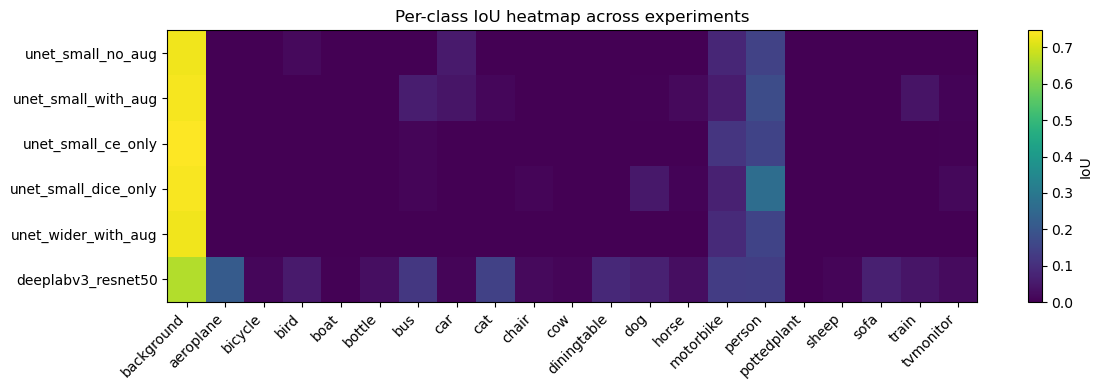


Best overall experiment by mIoU: deeplabv3_resnet50


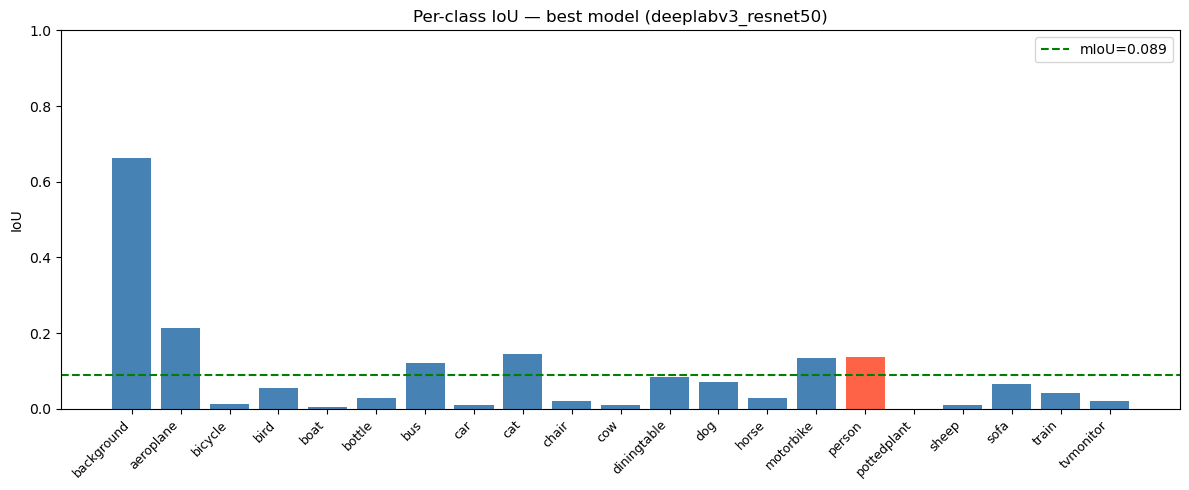


Person-class ranking:


,experiment,human_iou,human_accuracy,hd95_person
1,unet_small_dice_only,0.2660,0.4935,76.7078
4,unet_small_ce_only,0.1510,0.3702,85.5471
3,unet_small_no_aug,0.1483,0.4035,90.8778
2,unet_small_with_aug,0.1477,0.3582,91.0327
5,unet_wider_with_aug,0.1459,0.4503,97.4451
0,deeplabv3_resnet50,0.1368,0.3150,92.8063


In [23]:
if experiment_results:
    print("Per-class IoU table:")
    display(per_class_df)

    plot_per_class_heatmap(per_class_df, title="Per-class IoU heatmap across experiments")
    plt.show()

    best_experiment = summary_df.iloc[0]["experiment"]
    print(f"\nBest overall experiment by mIoU: {best_experiment}")
    plot_per_class_iou(experiment_results[best_experiment]["metrics"], title=f"Per-class IoU — best model ({best_experiment})")
    plt.show()

    person_table = summary_df[["experiment", "human_iou", "human_accuracy", "hd95_person"]].sort_values(by="human_iou", ascending=False)
    print("\nPerson-class ranking:")
    display(person_table.round(4))
else:
    print("No experiment metrics loaded.")


### Qualitative analysis note

To keep the report readable, the next figures focus on the top-performing models by mIoU rather than dumping every experiment.

In [24]:
if experiment_results:
    if any(result["examples"] for result in experiment_results.values()):
        qualitative_experiments = (
            summary_df["experiment"].head(TOP_K_QUALITATIVE_MODELS).tolist()
            if "summary_df" in globals()
            else [name for name, result in experiment_results.items() if result["examples"]][:TOP_K_QUALITATIVE_MODELS]
        )
        print(f"Showing qualitative mosaics for the top {len(qualitative_experiments)} models by mIoU: {qualitative_experiments}")
        for exp_name in qualitative_experiments:
            result = experiment_results[exp_name]
            if not result["examples"]:
                continue
            show_prediction_mosaic(
                result["examples"],
                title=f"Segmentation mosaic — {exp_name}",
                n_cols=4,
                max_items=12,
            )
            plt.show()
    else:
        print(
            "Qualitative mosaics are unavailable because no validation examples were regenerated. "
            "Keep REGENERATE_QUALITATIVE_EXAMPLES = True for the report path."
        )
else:
    print("No experiment results loaded.")


Showing qualitative mosaics for the top 3 models by mIoU: ['deeplabv3_resnet50', 'unet_small_dice_only', 'unet_small_with_aug']


### Best/worst person examples (optional qualitative rerun)

In [25]:
if experiment_results:
    if any(result["examples"] for result in experiment_results.values()):
        qualitative_experiments = (
            summary_df["experiment"].head(TOP_K_QUALITATIVE_MODELS).tolist()
            if "summary_df" in globals()
            else [name for name, result in experiment_results.items() if result["examples"]][:TOP_K_QUALITATIVE_MODELS]
        )
        for exp_name in qualitative_experiments:
            result = experiment_results[exp_name]
            if not result["examples"]:
                continue
            print(f"\n--- {exp_name} ---")
            show_best_and_worst_person_examples(result["examples"], count=3)
            plt.show()
    else:
        print(
            "Best/worst person examples are unavailable because no validation examples were regenerated. "
            "Keep REGENERATE_QUALITATIVE_EXAMPLES = True for the report path."
        )
else:
    print("No experiment results loaded.")


### Confusion matrices from saved checkpoint metrics

Showing confusion matrices for the top 3 models by mIoU: ['deeplabv3_resnet50', 'unet_small_dice_only', 'unet_small_with_aug']


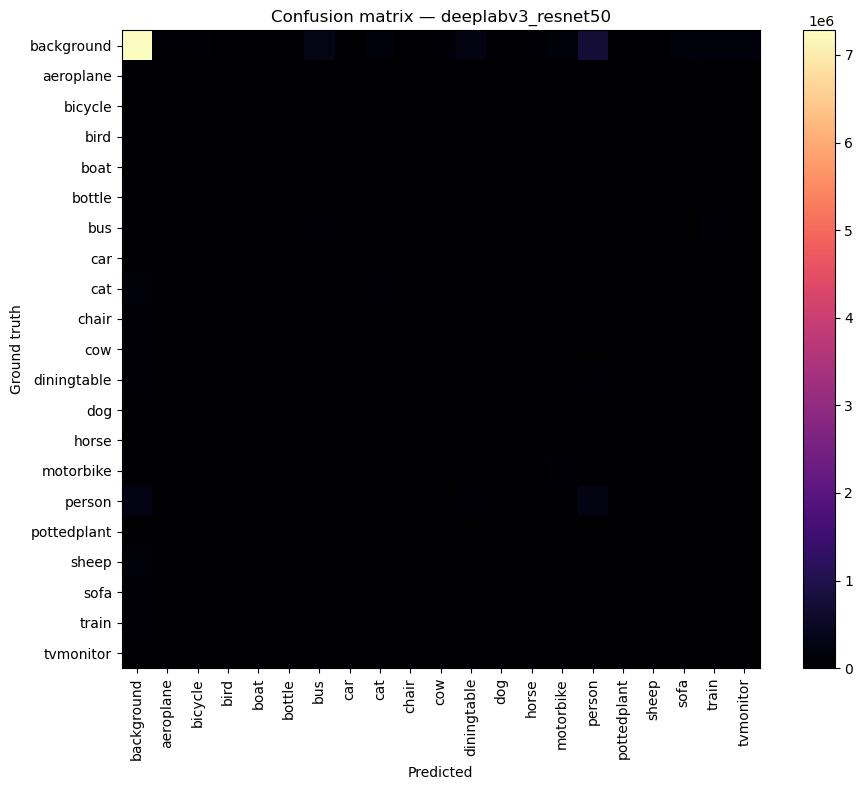

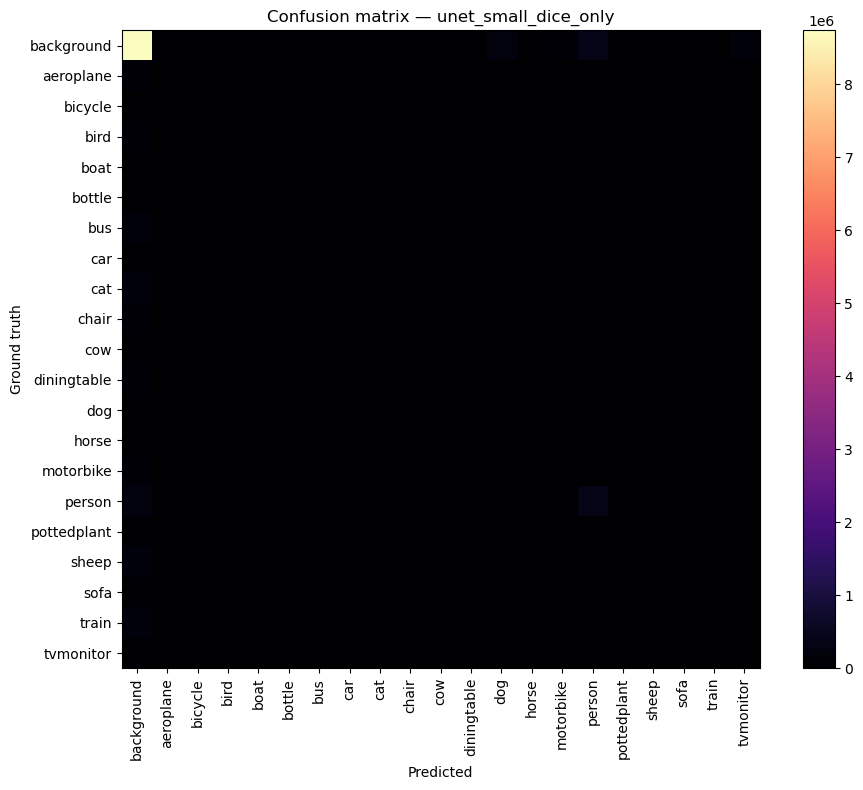

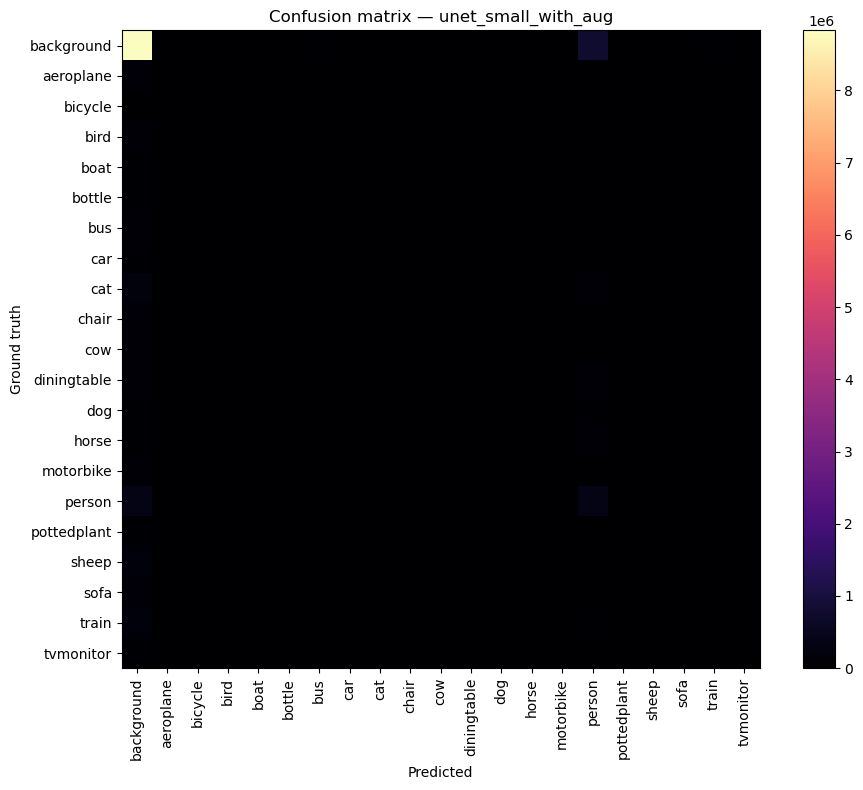

In [26]:
if experiment_results:
    top_experiments = summary_df["experiment"].head(3).tolist()
    print(f"Showing confusion matrices for the top {len(top_experiments)} models by mIoU: {top_experiments}")
    for exp_name in top_experiments:
        plot_confusion_matrix(experiment_results[exp_name]["confusion_matrix"], title=f"Confusion matrix — {exp_name}")
        plt.show()
else:
    print("No experiment results loaded.")


### Report-ready ablation interpretation

These deltas are intended to be copied into the written report and followed with a short explanation of *why* the change helped or hurt.

In [27]:
if "experiment_results" in globals() and experiment_results:
    if "ablation_df" not in globals():
        ablation_df = build_ablation_dataframe(experiment_results).round(4)
    for _, row in ablation_df.iterrows():
        print(f"\n=== {row['ablation']} ===")
        print(f"Baseline   : {row['baseline']}")
        print(f"Comparison : {row['comparison']}")
        print(f"- mIoU delta        : {row['delta_mIoU']:+.4f}")
        print(f"- mean Dice delta   : {row['delta_mean_dice']:+.4f}")
        print(f"- pixel accuracy Δ  : {row['delta_pixel_accuracy']:+.4f}")
        print(f"- person IoU delta  : {row['delta_human_iou']:+.4f}")
        print(f"- HD95 delta        : {row['delta_hd95_person']:+.4f} (lower is better)")
        print(f"- val loss delta    : {row['delta_val_loss']:+.4f} (lower is better)")
else:
    print("Run the main training/evaluation cell first so experiment_results is available.")



=== Augmentation ===
Baseline   : unet_small_no_aug
Comparison : unet_small_with_aug
- mIoU delta        : +0.0057
- mean Dice delta   : +0.0101
- pixel accuracy Δ  : +0.0023
- person IoU delta  : +0.0254
- HD95 delta        : +0.6125 (lower is better)
- val loss delta    : -0.0398 (lower is better)

=== Loss function (CE vs Dice) ===
Baseline   : unet_small_ce_only
Comparison : unet_small_dice_only
- mIoU delta        : +0.0067
- mean Dice delta   : +0.0109
- pixel accuracy Δ  : -0.0276
- person IoU delta  : +0.1159
- HD95 delta        : -5.2746 (lower is better)
- val loss delta    : -2.2131 (lower is better)

=== Model size (small vs wide) ===
Baseline   : unet_small_with_aug
Comparison : unet_wider_with_aug
- mIoU delta        : -0.0082
- mean Dice delta   : -0.0153
- pixel accuracy Δ  : +0.0012
- person IoU delta  : -0.0235
- HD95 delta        : +5.4794 (lower is better)
- val loss delta    : +0.0333 (lower is better)

=== Architecture (U-Net vs DeepLab) ===
Baseline   : unet_sma

## Optional SAM / SAM2 evaluation path

The assignment mentions the Segment Anything family. In practice, SAM/SAM2 is not a drop-in supervised semantic segmentation model like U-Net or DeepLab. A reasonable homework extension is to treat it as a **prompted segmentation baseline** using boxes or points derived from the target object of interest (for example, the `person` class).

The helper below:
- tries to import SAM2
- fails gracefully if unavailable
- supports a **person-class prompted** experiment using a bounding box extracted from the ground-truth mask

You can adapt this section for a more ambitious prompt-generation strategy or to compare multiple prompt types.

In [28]:
def load_optional_sam2_predictor(config_path: str, checkpoint_path: str):
    try:
        from sam2.build_sam import build_sam2
        from sam2.sam2_image_predictor import SAM2ImagePredictor
    except Exception as exc:
        print("SAM2 is unavailable in this environment:", exc)
        return None

    sam_model = build_sam2(config_path, checkpoint_path, device=device)
    predictor = SAM2ImagePredictor(sam_model)
    return predictor


def mask_to_box(mask: np.ndarray, class_id: int = PERSON_CLASS_ID):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return np.array([xs.min(), ys.min(), xs.max(), ys.max()], dtype=np.float32)


def run_sam2_person_prompt(predictor, image: np.ndarray, gt_mask: np.ndarray, class_id: int = PERSON_CLASS_ID):
    box = mask_to_box(gt_mask, class_id=class_id)
    if box is None:
        return None
    predictor.set_image((image * 255).astype(np.uint8))
    masks, scores, _ = predictor.predict(box=box[None, :], multimask_output=False)
    return {
        "pred_mask": masks[0].astype(np.uint8),
        "score": float(scores[0]),
        "hd95_person": binary_hd95(masks[0] > 0, gt_mask == class_id),
    }

## Suggested ablation studies to include in the report

At least two ablations are required. The notebook is already set up for these:

1. **Data augmentation:** `unet_small_no_aug` vs `unet_small_with_aug`
2. **Model family / backbone:** `UNet` vs `DeepLabV3-ResNet50`
3. **Loss function:** duplicate an experiment and switch `loss_name` between `ce`, `dice`, and `ce_dice`
4. **Model size:** create `unet_wider` by increasing the feature list to `(64, 128, 256, 512)`
5. **Pretraining:** if your environment already has pretrained weights cached, compare scratch vs pretrained-backbone variants

## Report checklist

Before submission, make sure your final report includes:

- at least two segmentation approaches plus one or more meaningful modifications / ablations
- model architectures and why you chose them
- training setup, dataset split, and hyperparameters
- quantitative results table (Dice, mIoU, pixel accuracy, HD95, per-class metrics)
- qualitative figures for the strongest models (mosaic + best 3 / worst 3, especially the `person` class)
- at least two ablation findings with metric deltas and interpretation
- interpretation of strengths, failure modes, class imbalance effects, and lessons learned

This notebook is intended to be the code appendix / experimental backbone for that report.

In [29]:
# Optional export helpers after you finish training or after loading saved checkpoints.

def save_metrics_json(result: Dict, out_path: str):
    serializable = {
        "name": result["name"],
        "metrics": result["metrics"],
        "history": result["history"].to_dict(orient="records"),
    }
    resolved_out = resolve_notebook_relative_path(out_path, must_exist=False)
    resolved_out.parent.mkdir(parents=True, exist_ok=True)
    resolved_out.write_text(json.dumps(serializable, indent=2))
    print(f"Saved metrics to {resolved_out}")


def dataframe_to_markdown(df: pd.DataFrame, float_digits: int = 4) -> str:
    display_df = df.copy()
    for column in display_df.columns:
        if pd.api.types.is_float_dtype(display_df[column]):
            display_df[column] = display_df[column].map(lambda value: f"{value:.{float_digits}f}")
    headers = list(display_df.columns)
    rows = [headers, ["---"] * len(headers)]
    rows.extend(display_df.astype(str).values.tolist())
    return "\n".join("| " + " | ".join(row) + " |" for row in rows)


def export_report_artifacts(results: Dict[str, Dict], out_dir: str = "artifacts/report_exports"):
    resolved_dir = resolve_notebook_relative_path(out_dir, must_exist=False)
    resolved_dir.mkdir(parents=True, exist_ok=True)

    summary_df = summarize_experiments(results).reset_index(drop=True)
    summary_path = resolved_dir / "experiment_summary.csv"
    summary_df.to_csv(summary_path, index=False)

    per_class_rows = []
    for name, result in results.items():
        row = {"experiment": name}
        row.update(result["metrics"]["per_class_iou"])
        per_class_rows.append(row)
    per_class_df = pd.DataFrame(per_class_rows).set_index("experiment").round(6)
    per_class_path = resolved_dir / "per_class_iou.csv"
    per_class_df.to_csv(per_class_path)

    ablation_pairs = [
        ("Augmentation", "unet_small_no_aug", "unet_small_with_aug"),
        ("Loss function (CE vs Dice)", "unet_small_ce_only", "unet_small_dice_only"),
        ("Model size (small vs wide)", "unet_small_with_aug", "unet_wider_with_aug"),
        ("Architecture (U-Net vs DeepLab)", "unet_small_with_aug", "deeplabv3_resnet50"),
    ]
    ablation_rows = []
    markdown_lines = [
        "# Segmentation experiment summary",
        "",
        "## Ranked summary (by mIoU)",
        "",
        dataframe_to_markdown(summary_df),
        "",
        "## Ablation deltas",
        "",
    ]

    for ablation_name, exp_a, exp_b in ablation_pairs:
        if exp_a not in results or exp_b not in results:
            continue
        metrics_a = results[exp_a]["metrics"]
        metrics_b = results[exp_b]["metrics"]
        row = {
            "ablation": ablation_name,
            "baseline": exp_a,
            "comparison": exp_b,
        }
        markdown_lines.append(f"### {ablation_name}")
        markdown_lines.append("")
        for metric_name in ["mIoU", "mean_dice", "pixel_accuracy", "human_iou", "hd95_person"]:
            delta = metrics_b[metric_name] - metrics_a[metric_name]
            row[f"delta_{metric_name}"] = delta
            markdown_lines.append(
                f"- **{metric_name}**: {metrics_a[metric_name]:.4f} -> {metrics_b[metric_name]:.4f} (delta {delta:+.4f})"
            )
        markdown_lines.append("")
        ablation_rows.append(row)

    ablation_df = pd.DataFrame(ablation_rows)
    ablation_path = resolved_dir / "ablation_summary.csv"
    ablation_df.to_csv(ablation_path, index=False)

    markdown_path = resolved_dir / "report_summary.md"
    markdown_path.write_text("\n".join(markdown_lines) + "\n")

    print(f"Saved summary CSV to {summary_path}")
    print(f"Saved per-class IoU CSV to {per_class_path}")
    print(f"Saved ablation CSV to {ablation_path}")
    print(f"Saved markdown summary to {markdown_path}")

    return {
        "summary_csv": summary_path,
        "per_class_csv": per_class_path,
        "ablation_csv": ablation_path,
        "markdown": markdown_path,
    }

# Example:
# for name, result in experiment_results.items():
#     save_metrics_json(result, f"artifacts/{name}_metrics.json")
# export_report_artifacts(experiment_results)


In [30]:
if experiment_results:
    exported_artifacts = export_report_artifacts(experiment_results)
    exported_artifacts
else:
    print("No experiment results available to export yet.")


Saved summary CSV to /shared/home/qiz788/SHBT2/artifacts/report_exports/experiment_summary.csv
Saved per-class IoU CSV to /shared/home/qiz788/SHBT2/artifacts/report_exports/per_class_iou.csv
Saved ablation CSV to /shared/home/qiz788/SHBT2/artifacts/report_exports/ablation_summary.csv
Saved markdown summary to /shared/home/qiz788/SHBT2/artifacts/report_exports/report_summary.md


In [31]:
if experiment_results:
    qualitative_experiments = summary_df["experiment"].head(TOP_K_QUALITATIVE_MODELS).tolist()
    best_overall = summary_df.iloc[0]
    best_person = summary_df.loc[summary_df["human_iou"].idxmax()]
    strongest_non_background = (
        per_class_df.drop(columns=["background"], errors="ignore").fillna(0.0).max().sort_values(ascending=False)
    )
    weakest_non_background = (
        per_class_df.drop(columns=["background"], errors="ignore").fillna(0.0).max().sort_values(ascending=True)
    )

    report_lines = [
        "# Report-ready synthesis",
        "",
        "## Requirement coverage",
        "",
        "- Two segmentation families are evaluated: custom U-Net variants and DeepLabV3-ResNet50.",
        "- Multiple ablations are included: augmentation, loss function, model width, and architecture family.",
        "- Quantitative metrics include Dice, mIoU, pixel accuracy, HD95 for the person class, and per-class IoU/accuracy.",
        "- Qualitative evidence includes mosaics plus best/worst person-class examples for the top-ranked models.",
        "",
        "## Suggested write-up",
        "",
        (
            f"The best overall model by mIoU is {best_overall['experiment']} "
            f"(mIoU={best_overall['mIoU']:.4f}, mean Dice={best_overall['mean_dice']:.4f}, "
            f"pixel accuracy={best_overall['pixel_accuracy']:.4f})."
        ),
        (
            f"The strongest model for the report's human-focused qualitative discussion is {best_person['experiment']}, "
            f"which achieves the best person IoU at {best_person['human_iou']:.4f} "
            f"with person accuracy {best_person['human_accuracy']:.4f}."
        ),
        (
            "A useful interpretation angle is that ranking by global mIoU and ranking by the person class do not perfectly agree, "
            "which shows that aggregate overlap can hide class-specific strengths and weaknesses."
        ),
        (
            f"The top qualitative sections focus on {qualitative_experiments}, which keeps the report concise while still showing best-case and failure-case predictions."
        ),
        (
            f"The strongest non-background classes across all experiments are {', '.join(strongest_non_background.head(5).index.tolist())}, "
            f"while the weakest classes are {', '.join(weakest_non_background.head(5).index.tolist())}; this supports a failure-mode discussion around class imbalance and small-object difficulty."
        ),
        "",
        "## Ablation talking points",
        "",
    ]

    for _, row in ablation_df.iterrows():
        report_lines.append(
            (
                f"- {row['ablation']}: mIoU {row['baseline_mIoU']:.4f} -> {row['comparison_mIoU']:.4f} "
                f"(Δ {row['delta_mIoU']:+.4f}), person IoU {row['baseline_human_iou']:.4f} -> {row['comparison_human_iou']:.4f} "
                f"(Δ {row['delta_human_iou']:+.4f}), HD95 {row['baseline_hd95_person']:.2f} -> {row['comparison_hd95_person']:.2f} "
                f"(Δ {row['delta_hd95_person']:+.2f}; lower is better)."
            )
        )

    report_lines.extend([
        "",
        "## Final recommendation",
        "",
        (
            "In the final report, explicitly distinguish the best *overall* model from the best *person-class* model, "
            "and use both the quantitative tables and the qualitative best/worst examples to explain that tradeoff."
        ),
    ])

    report_brief_path = resolve_notebook_relative_path("artifacts/report_exports/report_brief.md", must_exist=False)
    report_brief_path.parent.mkdir(parents=True, exist_ok=True)
    report_brief_path.write_text("\n".join(report_lines) + "\n")
    print("\n".join(report_lines))
    print(f"\nSaved report-ready synthesis to {report_brief_path}")
else:
    print("Run the analysis cells first so summary_df, per_class_df, and ablation_df are available.")


# Report-ready synthesis

## Requirement coverage

- Two segmentation families are evaluated: custom U-Net variants and DeepLabV3-ResNet50.
- Multiple ablations are included: augmentation, loss function, model width, and architecture family.
- Quantitative metrics include Dice, mIoU, pixel accuracy, HD95 for the person class, and per-class IoU/accuracy.
- Qualitative evidence includes mosaics plus best/worst person-class examples for the top-ranked models.

## Suggested write-up

The best overall model by mIoU is deeplabv3_resnet50 (mIoU=0.0891, mean Dice=0.1414, pixel accuracy=0.5977).
The strongest model for the report's human-focused qualitative discussion is unet_small_dice_only, which achieves the best person IoU at 0.2660 with person accuracy 0.4935.
A useful interpretation angle is that ranking by global mIoU and ranking by the person class do not perfectly agree, which shows that aggregate overlap can hide class-specific strengths and weaknesses.
The top qualitative sections fo